mport Required Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [3]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
print("Dataset Shape:", df.shape)


Dataset Shape: (7043, 21)


In [6]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [9]:
# Convert TotalCharges into numeric
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

# Check missing values again
print(df.isnull().sum())

# Remove null rows
df.dropna(inplace=True)

# Check duplicates
print("Duplicate Rows:", df.duplicated().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64
Duplicate Rows: 0


In [10]:
df['Churn'].value_counts()

,count
Churn,
No,5163
Yes,1869


In [11]:
churn_rate = (
    df['Churn'].value_counts(normalize=True) * 100
)

print(churn_rate)

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


Exploratory Data Analysis (EDA)

Churn Distribution

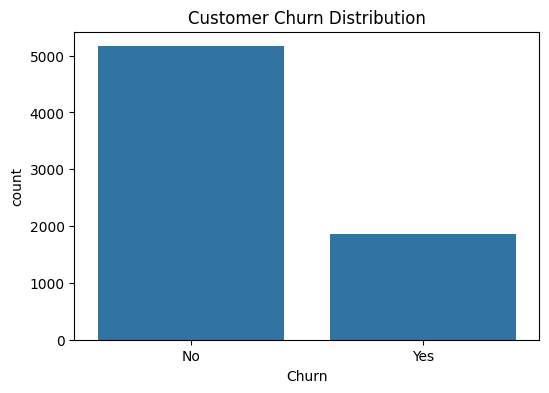

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(x='Churn', data=df)

plt.title("Customer Churn Distribution")
plt.show()

Churn Percentage Pie Chart

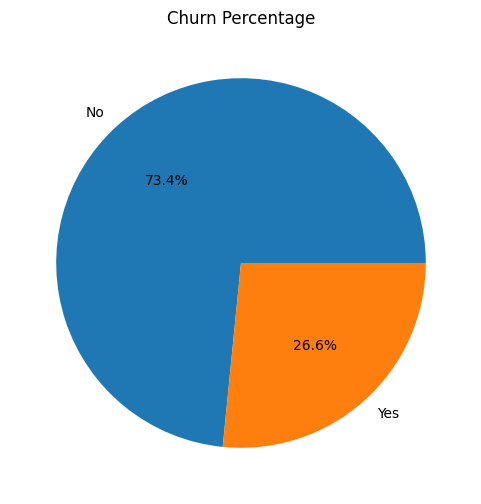

In [13]:
churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    churn_counts,
    labels=churn_counts.index,
    autopct='%1.1f%%'
)

plt.title("Churn Percentage")
plt.show()

Contract Type vs Churn

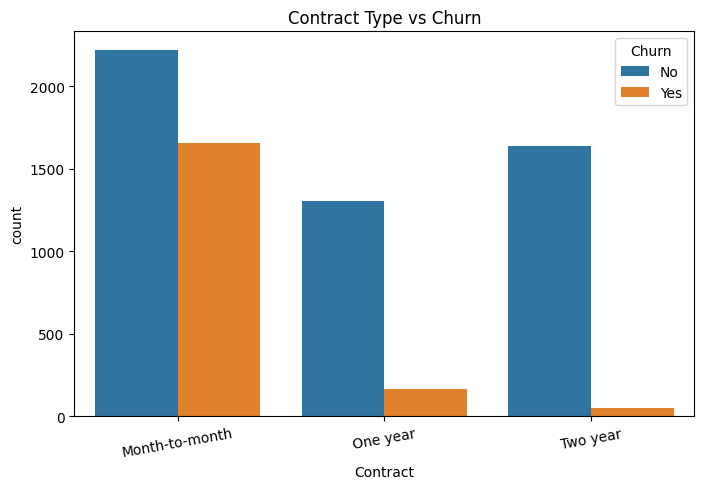

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Contract',
    hue='Churn',
    data=df
)

plt.title("Contract Type vs Churn")
plt.xticks(rotation=10)

plt.show()

Internet Service vs Churn

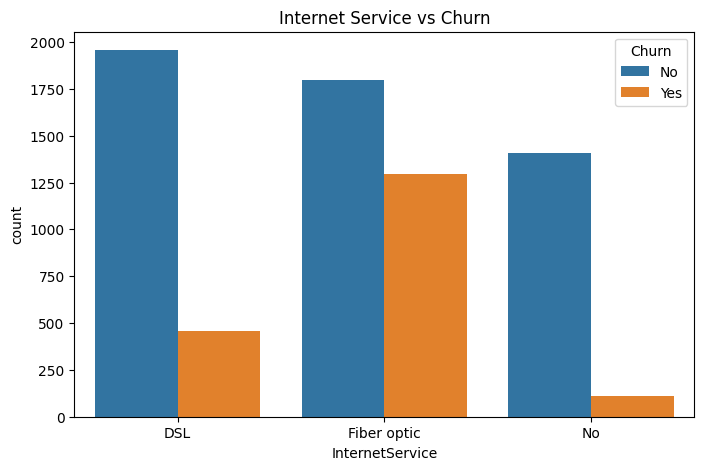

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='InternetService',
    hue='Churn',
    data=df
)

plt.title("Internet Service vs Churn")

plt.show()

Monthly Charges Distribution


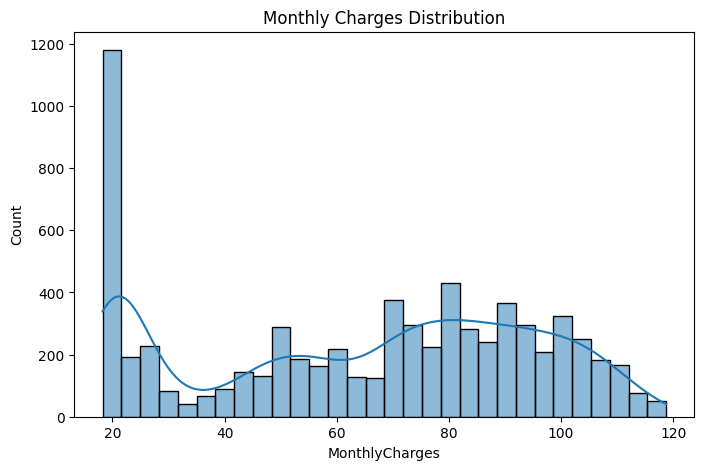

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['MonthlyCharges'],
    bins=30,
    kde=True
)

plt.title("Monthly Charges Distribution")

plt.show()

Tenure Distribution

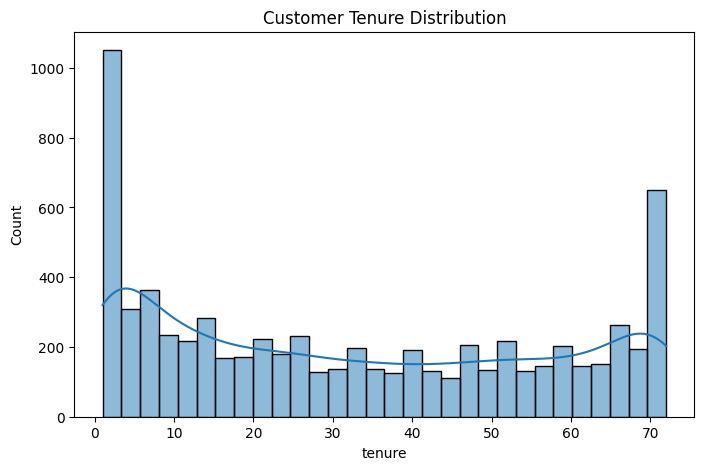

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['tenure'],
    bins=30,
    kde=True
)

plt.title("Customer Tenure Distribution")

plt.show()

Correlation Heatmap

In [18]:
df['Churn'] = df['Churn'].map({
    'Yes':1,
    'No':0
})

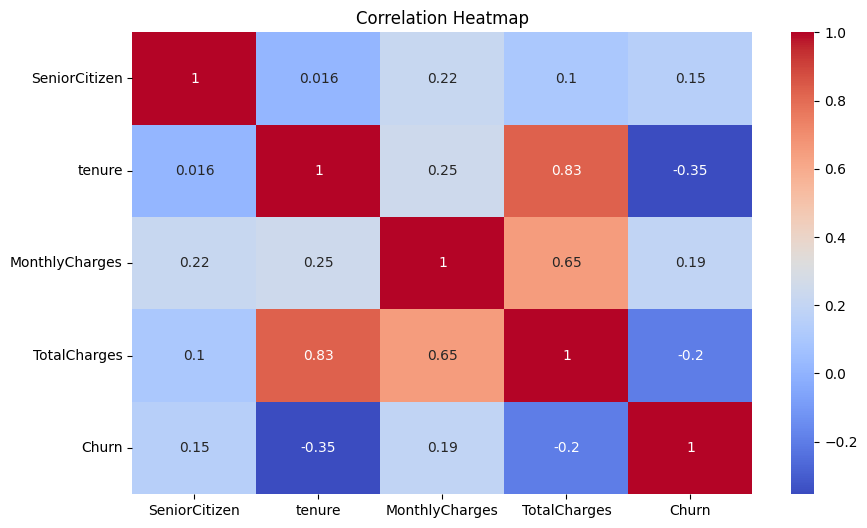

In [19]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

Feature Engineering + Data Preparation for ML

Separate Features and Target

In [20]:
X = df.drop('Churn', axis=1)
y = df['Churn']

Remove customerID

In [21]:
X = X.drop('customerID', axis=1)

Convert Categorical Columns

In [22]:
X = pd.get_dummies(X, drop_first=True)

Check Converted Dataset

In [23]:
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


Train/Test Split

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [32]:
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [33]:
print("Dataset Shape:", df.shape)


Dataset Shape: (7032, 21)


Feature Scaling

In [26]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Model Training Phase**

Install XGBoost

In [27]:
!pip install xgboost

Import XGBoost

In [28]:
from xgboost import XGBClassifier

Create Model

In [29]:
model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

Train The Model

In [30]:
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

Make Predictions

In [31]:
y_pred = model.predict(X_test)

Accuracy

In [34]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7739872068230277


Detailed Classification Report

In [35]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1033
           1       0.59      0.50      0.54       374

    accuracy                           0.77      1407
   macro avg       0.71      0.69      0.69      1407
weighted avg       0.76      0.77      0.77      1407



Feature Importance

In [36]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

                           Feature  Importance
10     InternetService_Fiber optic    0.442295
25               Contract_Two year    0.176434
11              InternetService_No    0.096233
24               Contract_One year    0.069075
23             StreamingMovies_Yes    0.021668
1                           tenure    0.021254
7                 PhoneService_Yes    0.013918
13              OnlineSecurity_Yes    0.013337
21                 StreamingTV_Yes    0.012761
28  PaymentMethod_Electronic check    0.012183


Plot Feature Importance

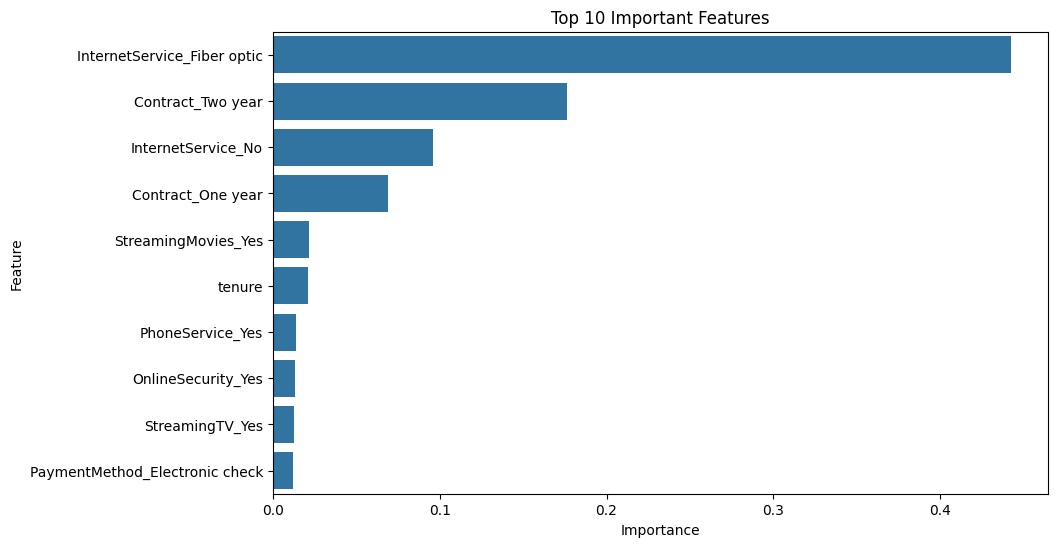

In [37]:
  top_features = importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features
)

plt.title("Top 10 Important Features")

plt.show()

SHAP Explainability

Install SHAP

In [38]:
!pip install shap

Import SHAP

In [39]:
import shap

Create SHAP Explainer

In [40]:
explainer = shap.Explainer(model)

Generate SHAP Values

In [41]:
shap_values = explainer(X_test)

SHAP Summary Plot

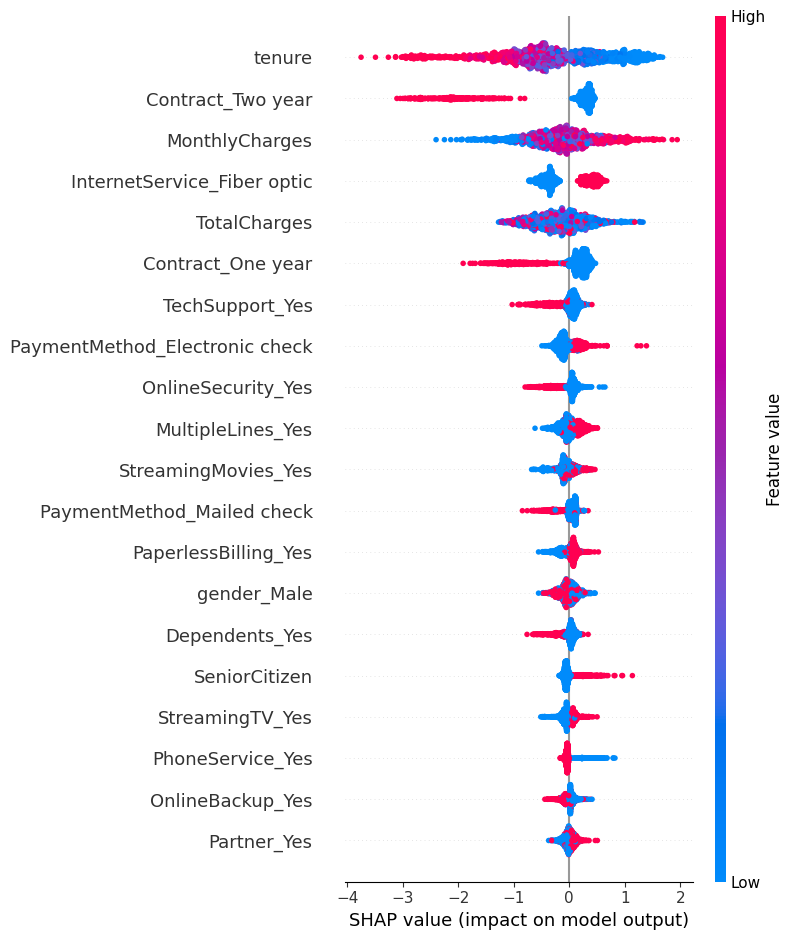

In [42]:
shap.summary_plot(shap_values, X_test)

SHAP explanations for 5 individual customers

In [43]:
sample_customers = X_test.iloc[:5]

In [44]:
sample_shap_values = explainer(sample_customers)

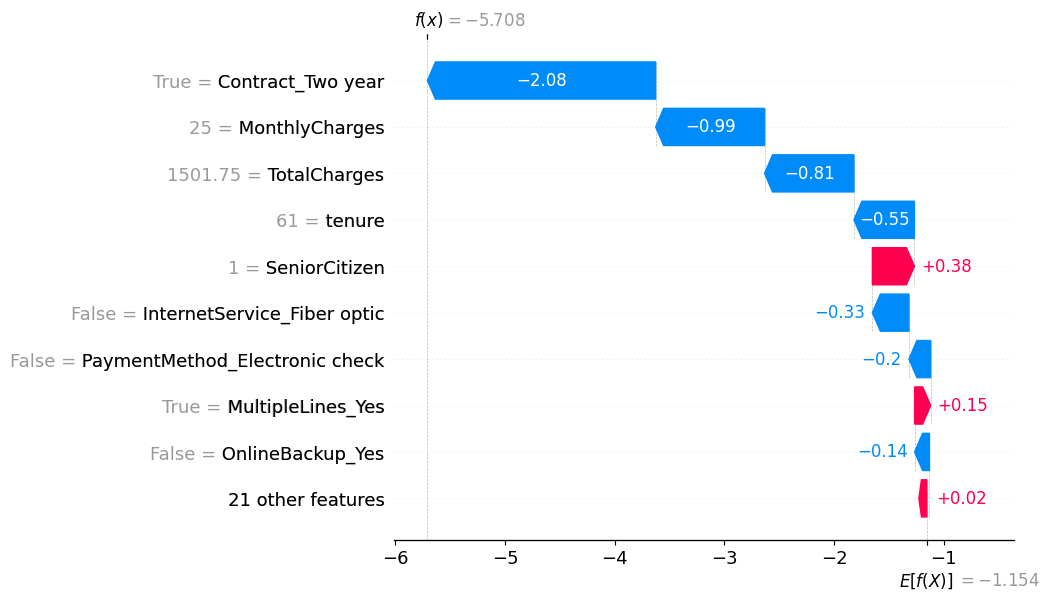

In [45]:
shap.plots.waterfall(sample_shap_values[0])

Repeat For All 5 Customers

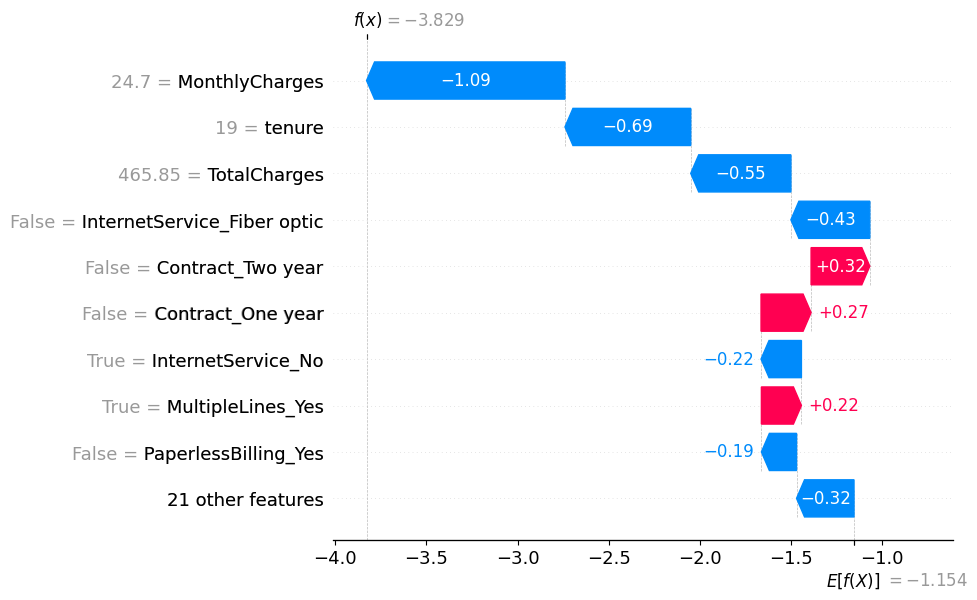

In [46]:
shap.plots.waterfall(sample_shap_values[1])

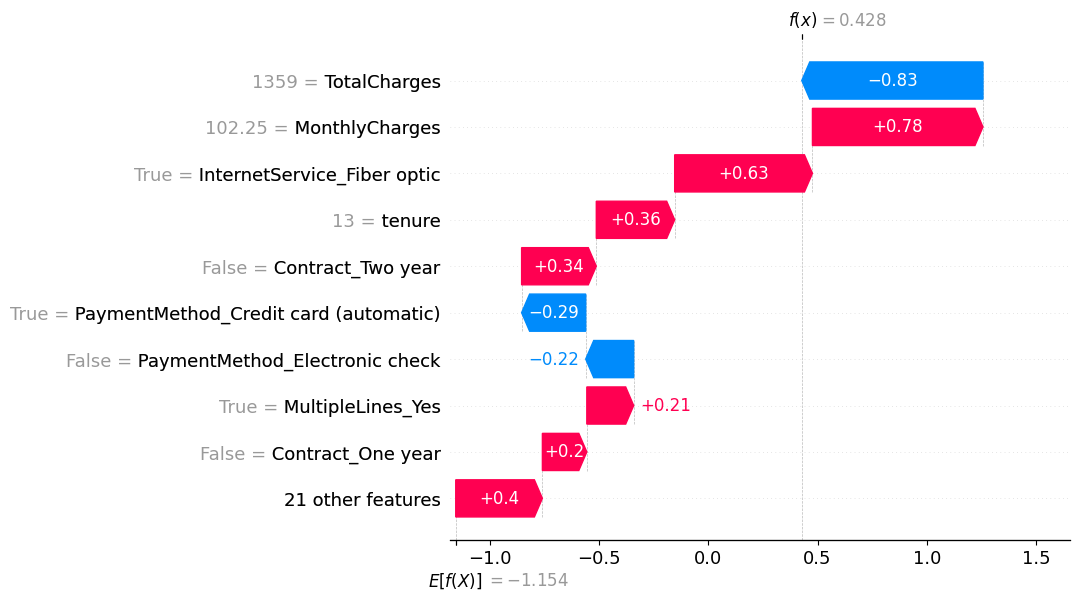

In [47]:
shap.plots.waterfall(sample_shap_values[2])

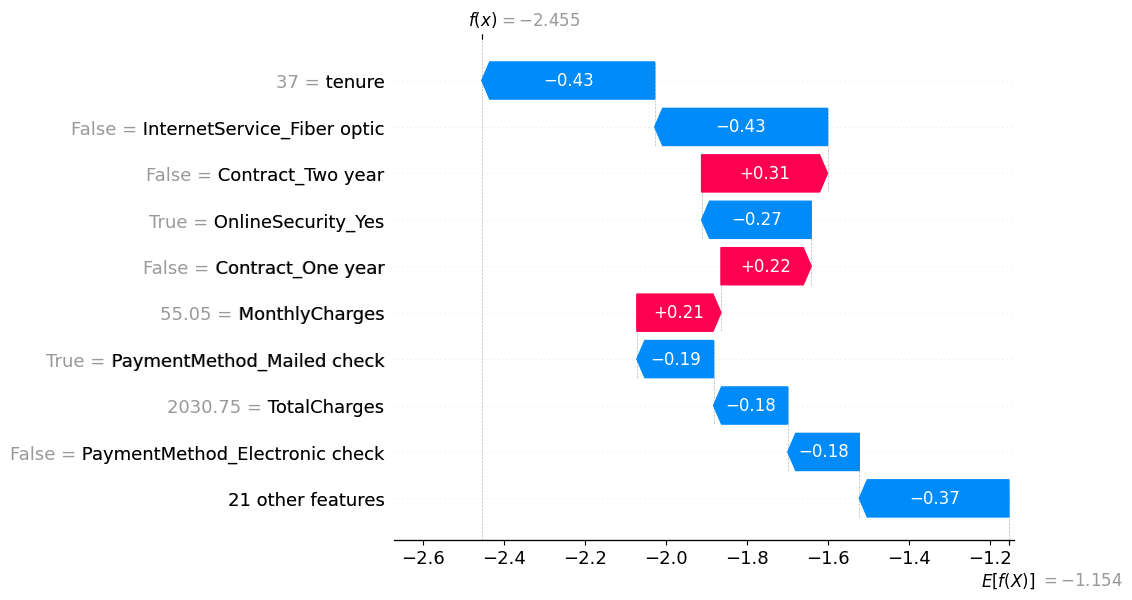

In [48]:
shap.plots.waterfall(sample_shap_values[3])

Customer Lifetime Value (LTV) Engine

Create LTV Column

In [50]:
df['LTV'] = df['MonthlyCharges'] * df['tenure']

View LTV

In [51]:
df[['MonthlyCharges', 'tenure', 'LTV']].head()

,MonthlyCharges,tenure,LTV
0,29.85,1,29.85
1,56.95,34,1936.30
2,53.85,2,107.70
3,42.30,45,1903.50
4,70.70,2,141.40


Create Customer Segments

In [55]:
def segment_ltv(value):
    if value < 2000:
        return "Low Value"
    elif value < 5000:
        return "Medium Value"
    else:
        return "High Value"

df['LTV_Segment'] = df['LTV'].apply(segment_ltv)

LTV Distribution

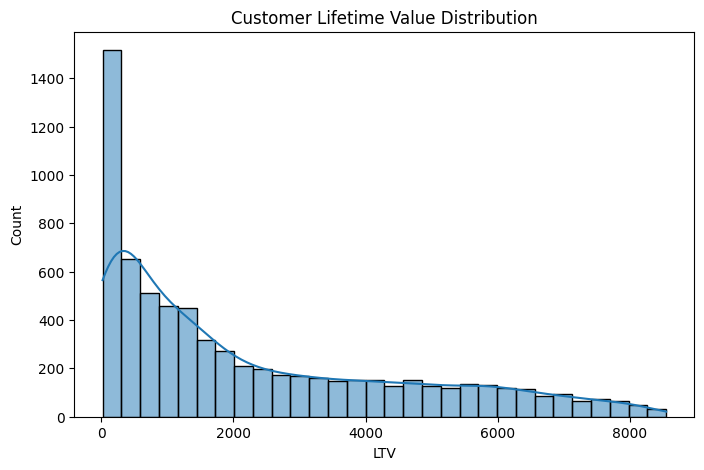

In [52]:
plt.figure(figsize=(8,5))

sns.histplot(df['LTV'], bins=30, kde=True)

plt.title("Customer Lifetime Value Distribution")

plt.show()

Count Segments

In [56]:
df['LTV_Segment'].value_counts()

,count
LTV_Segment,
Low Value,4174
Medium Value,1715
High Value,1143


Visualize LTV Segments

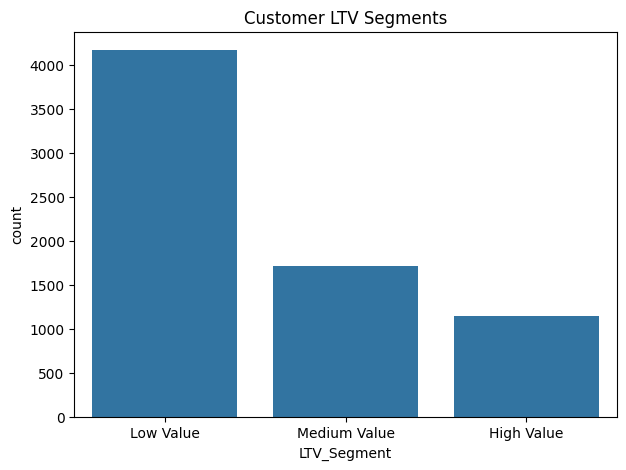

In [57]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='LTV_Segment',
    data=df,
    order=['Low Value', 'Medium Value', 'High Value']
)

plt.title("Customer LTV Segments")

plt.show()

Churn vs LTV Segment

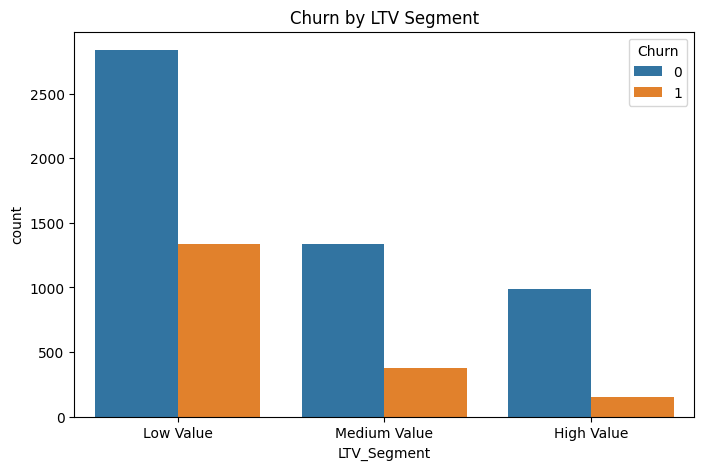

In [58]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='LTV_Segment',
    hue='Churn',
    data=df,
    order=['Low Value', 'Medium Value', 'High Value']
)

plt.title("Churn by LTV Segment")

plt.show()

Save Trained Model

In [59]:
import joblib

joblib.dump(model, 'churn_model.pkl')

print("Model Saved Successfully!")

Model Saved Successfully!


install fast api

In [60]:
!pip install fastapi uvicorn nest-asyncio pyngrok